In [ ]:
"""
Hospital Management Data Warehouse Project
-------------------------------------------
Author: Alex Larose
Description:
This project builds a hospital data warehouse using SQLite
following a Star Schema design. It includes:

- Dimension tables (Patients, Doctors, Departments, etc.)
- Fact tables for patient visits (partitioned by year)
- Data cleaning preparation table
- Analytical SQL queries
- Data visualization using Matplotlib

Tools Used:
- Python
- SQLite
- Pandas
- Matplotlib
"""

In [ ]:
# # import libraries
import sqlite3 # create and manage a local SQL database
import pandas as pd # data manipulation and analysis
import matplotlib.pyplot as plt # Used for data visualization
conn = sqlite3.connect("hospital.db") # Create a connection to a SQLite database file

In [ ]:
# ==========================================================
# STAR SCHEMA DESIGN
# ----------------------------------------------------------
# This database follows a Star Schema architecture:
#
# - Dimension Tables store descriptive information
# - Fact Tables store transactional visit data
#
# Dimension Tables:
#   Dim_Patient
#   Dim_Doctor
#   Dim_Department
#   Dim_Diagnosis
#   Dim_Treatment
#   Dim_PaymentMethod
#
# Fact Tables:
#   PatientVisits_2020_2021
#   PatientVisits_2022_2023
#   PatientVisits_2024
#   PatientVisits_2025
#
# ==========================================================

In [ ]:
# ---------------------------------------------------
# Create Dimension Table: Dim_Patient
# Stores demographic information about patients
# Primary Key: PatientID
# ---------------------------------------------------
conn.execute("""
CREATE TABLE Dim_Patient (
  PatientID varchar(20) PRIMARY KEY,
  FirstName varchar(50),
  LastName varchar(50),
  Gender varchar(10),
  DOB date,
  CityStateCountry varchar(150)
  );
  """)
conn.commit()
print("Dim_patient table created");

Dim_patient table created


In [ ]:
# ----------------------------------------------------------
# CREATE DIMENSION TABLE: Dim_Doctor
# Stores doctor profile and experience information
# Primary Key: DoctorID
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE Dim_Doctor (
  DoctorID varchar(20) PRIMARY KEY,
  FirstName varchar(50),
  LastName varchar(50),
  Gender varchar(10),
  ExperienceYears integer
  );
  """)
conn.commit()
print("Dim_Doctor table created");

Dim_Doctor table created


In [ ]:
# ----------------------------------------------------------
# CREATE DIMENSION TABLE: Dim_Department
# Stores hospital department information
# Primary Key: DepartmentID
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE Dim_Department (
  DepartmentID varchar(20) PRIMARY KEY,
  DepartmentName varchar(100),
  DepartmentCategory varchar(100),
  Specialization varchar(100),
  HOD varchar(30)
);
""")
conn.commit()
print("Dim_Department table created");

Dim_Department table created


In [ ]:
# ----------------------------------------------------------
# CREATE DIMENSION TABLE: Dim_Diagnosis
# Stores diagnosis categories
# Primary Key: DiagnosisID
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE Dim_Diagnosis (
  DiagnosisID varchar(20) PRIMARY KEY,
  DiagnosisName varchar(200)
);
""")
conn.commit()
print("Dim_Department table created");

Dim_Department table created


In [ ]:
# ----------------------------------------------------------
# CREATE DIMENSION TABLE: Dim_Treatment
# Stores available treatment types
# Primary Key: TreatmentID
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE Dim_Treatment (
  TreatmentID varchar(20) PRIMARY KEY,
  TreatmentName varchar(100)
  );"""
)
conn.commit()
print("Dim_Treatment table created");

Dim_Treatment table created


In [ ]:
# ----------------------------------------------------------
# CREATE FACT TABLE: PatientVisits_2020_2021
# Stores visit-level transactional data
# Includes revenue, wait time, satisfaction score
# Contains foreign key relationships to dimension tables
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE PatientVisits_2020_2021 (
  VisitID varchar(20) PRIMARY KEY,
  PatientID varchar(20),
  DoctorID varchar(20),
  DepartmentID varchar(20),
  DiagnosisID varchar(20),
  TreatmentID varchar(20),
  PaymentMethodID varchar(20),
  VisitDate date,
  VisitTime time,
  DischargeDate date,
  BillAmount decimal(18,2),
  InsuranceAmount decimal(18,2),
  SatisfactionScore integer,
  WaitTimeMinutes integer,
FOREIGN KEY (PatientID) REFERENCES Dim_Patient(PatientID),
FOREIGN KEY (DoctorID) REFERENCES Dim_Doctor(DoctorID),
FOREIGN KEY (DepartmentID) REFERENCES Dim_Department(DepartmentID),
FOREIGN KEY (DiagnosisID) REFERENCES Dim_Diagnosis(DiagnosisID),
FOREIGN KEY (TreatmentID) REFERENCES Dim_Treatment(TreatmentID),
FOREIGN KEY (PaymentMethodID) REFERENCES Dim_PaymentMethod(PaymentMethodID)
);"""
)
conn.commit()
print("PatientVisits_2020_2021 table created");

PatientVisits_2020_2021 table created


In [ ]:
# ----------------------------------------------------------
# CREATE FACT TABLE: PatientVisits_2022_2023
# Stores visit-level transactional data
# Includes revenue, wait time, satisfaction score
# Contains foreign key relationships to dimension tables
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE PatientVisits_2022_2023 (
  VisitID varchar(20) PRIMARY KEY,
  PatientID varchar(20),
  DoctorID varchar(20),
  DepartmentID varchar(20),
  DiagnosisID varchar(20),
  TreatmentID varchar(20),
  PaymentMethodID varchar(20),
  VisitDate date,
  VisitTime time,
  DischargeDate date,
  BillAmount decimal(18,2),
  InsuranceAmount decimal(18,2),
  SatisfactionScore integer,
  WaitTimeMinutes integer,
FOREIGN KEY (PatientID) REFERENCES Dim_Patient(PatientID),
FOREIGN KEY (DoctorID) REFERENCES Dim_Doctor(DoctorID),
FOREIGN KEY (DepartmentID) REFERENCES Dim_Department(DepartmentID),
FOREIGN KEY (DiagnosisID) REFERENCES Dim_Diagnosis(DiagnosisID),
FOREIGN KEY (TreatmentID) REFERENCES Dim_Treatment(TreatmentID),
FOREIGN KEY (PaymentMethodID) REFERENCES Dim_PaymentMethod(PaymentMethodID)
);
""")
conn.commit()
print("PatientVisits 2022 2023 table created ");

PatientVisits 2022 2023 table created 


In [ ]:
# ----------------------------------------------------------
# CREATE FACT TABLE: PatientVisits_2024
# Stores visit-level transactional data
# Includes revenue, wait time, satisfaction score
# Contains foreign key relationships to dimension tables
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE PatientVisits_2024 (
  VisitID varchar(20) PRIMARY KEY,
  PatientID varchar(20),
  DoctorID varchar(20),
  DepartmentID varchar(20),
  DiagnosisID varchar(20),
  TreatmentID varchar(20),
  PaymentMethodID varchar(20),
  VisitDate date,
  VisitTime time,
  DischargeDate date,
  BillAmount decimal(18,2),
  InsuranceAmount decimal(18,2),
  SatisfactionScore integer,
  WaitTimeMinutes integer,
FOREIGN KEY (PatientID) REFERENCES Dim_Patient(PatientID),
FOREIGN KEY (DoctorID) REFERENCES Dim_Doctor(DoctorID),
FOREIGN KEY (DepartmentID) REFERENCES Dim_Department(DepartmentID),
FOREIGN KEY (DiagnosisID) REFERENCES Dim_Diagnosis(DiagnosisID),
FOREIGN KEY (TreatmentID) REFERENCES Dim_Treatment(TreatmentID),
FOREIGN KEY (PaymentMethodID) REFERENCES Dim_PaymentMethod(PaymentMethodID)
);"""
)
conn.commit()
print("PatientVisits 2024 table created");

PatientVisits 2024 table created


In [ ]:
# ----------------------------------------------------------
# CREATE FACT TABLE: PatientVisits_2025
# Stores visit-level transactional data
# Includes revenue, wait time, satisfaction score
# Contains foreign key relationships to dimension tables
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE PatientVisits_2025 (
  VisitID varchar(20) PRIMARY KEY,
  PatientID varchar(20),
  DoctorID varchar(20),
  DepartmentID varchar(20),
  DiagnosisID varchar(20),
  TreatmentID varchar(20),
  PaymentMethodID varchar(20),
  VisitDate date,
  VisitTime time,
  DischargeDate date,
  BillAmount decimal(18,2),
  InsuranceAmount decimal(18,2),
  SatisfactionScore integer,
  WaitTimeMinutes integer,
FOREIGN KEY (PatientID) REFERENCES Dim_Patient(PatientID),
FOREIGN KEY (DoctorID) REFERENCES Dim_Doctor(DoctorID),
FOREIGN KEY (DepartmentID) REFERENCES Dim_Department(DepartmentID),
FOREIGN KEY (DiagnosisID) REFERENCES Dim_Diagnosis(DiagnosisID),
FOREIGN KEY (TreatmentID) REFERENCES Dim_Treatment(TreatmentID),
FOREIGN KEY (PaymentMethodID) REFERENCES Dim_PaymentMethod(PaymentMethodID)
  );"""
)
conn.commit()
print("PatientVisits 2025 table created");

PatientVisits 2025 table created


In [ ]:
# ----------------------------------------------------------
# CREATE CLEANING TABLE: Dim_Patient_Clean
# Used for data quality improvement
# Will store parsed and standardized patient information
# Splits CityStateCountry into separate fields
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE IF NOT EXISTS Dim_Patient_Clean (
    PatientID TEXT PRIMARY KEY,
    FullName TEXT,
    Gender TEXT,
    DOB TEXT,
    City TEXT,
    State TEXT,
    Country TEXT
)
""")
conn.commit()
print("Dim_Patient_Clean 2025 table created");

Dim_Patient_Clean 2025 table created


In [ ]:
# ----------------------------------------------------------
# CREATE DIMENSION TABLE: Dim_PaymentMethod
# Stores payment method options
# Primary Key: PaymentMethodID
# Simple lookup table for transaction payment types
# ----------------------------------------------------------
conn.execute("""
CREATE TABLE Dim_PaymentMethod (
  PaymentMethodID varchar(20) PRIMARY KEY,
  PaymentMethod varchar(50)
  );"""
)
conn.commit()
print("Dim_PaymentMethod table created");

Dim_PaymentMethod table created


In [ ]:
# ==========================================================
# DATA POPULATION - DIM_DOCTOR
# ----------------------------------------------------------
# Insert 40 doctor records with varied experience levels
# Data includes: ID, first name, last name, gender, years of experience
# ==========================================================

# Inserts for Dim_Doctor
conn.execute("INSERT INTO Dim_Doctor VALUES ('D001','Dr. Anita','Gupta','Female',17)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D002','Dr. Vikram','Patel','Male',3)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D003','Dr. Raj','Joshi','Male',33)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D004','Dr. Ritu','Malhotra','Female',15)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D005','Dr. Karan','Joshi','Male',28)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D006','Dr. Ritu','Reddy','Female',26)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D007','Dr. Pooja','Mehra','Female',26)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D008','Dr. Vikram','Singh','Male',25)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D009','Dr. Rohan','Singh','Male',18)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D010','Dr. Tanya','Patel','Female',9)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D011','Dr. Nisha','Khan','Female',23)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D012','Dr. Manish','Gupta','Male',25)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D013','Dr. Kavita','Malhotra','Female',17)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D014','Dr. Manish','Sharma','Male',32)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D015','Dr. Divya','Joshi','Female',30)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D016','Dr. Rohan','Sharma','Male',31)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D017','Dr. Priya','Singh','Female',33)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D018','Dr. Sneha','Verma','Female',25)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D019','Dr. Arjun','Joshi','Male',19)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D020','Dr. Priya','Joshi','Female',34)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D021','Dr. Rohan','Mehra','Male',16)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D022','Dr. Pooja','Malhotra','Female',22)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D023','Dr. Manish','Malhotra','Male',29)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D024','Dr. Karan','Joshi','Male',23)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D025','Dr. Tanya','Sharma','Female',25)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D026','Dr. Neha','Joshi','Female',7)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D027','Dr. Sneha','Gupta','Female',18)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D028','Dr. Sneha','Patel','Female',4)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D029','Dr. Divya','Verma','Female',24)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D030','Dr. Gaurav','Joshi','Male',27)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D031','Dr. Ritu','Khan','Female',11)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D032','Dr. Sneha','Verma','Female',22)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D033','Dr. Gaurav','Reddy','Male',34)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D034','Dr. Arjun','Mehra','Male',15)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D035','Dr. Amit','Singh','Male',31)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D036','Dr. Nisha','Reddy','Female',4)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D037','Dr. Priya','Malhotra','Female',6)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D038','Dr. Neha','Patel','Female',3)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D039','Dr. Nisha','Sharma','Female',3)")
conn.execute("INSERT INTO Dim_Doctor VALUES ('D040','Dr. Arjun','Sharma','Male',26)")
conn.commit()
conn.close()

In [ ]:
# ==========================================================
# VERIFY DATA INSERTION
# ----------------------------------------------------------
# Reconnect to database and display all doctor records
# Confirms successful data population
# ==========================================================
conn = sqlite3.connect('hospital.db')
cursor = conn.execute(''' SELECT * FROM Dim_Doctor''')
for row in cursor:
  print(row)

('D001', 'Dr. Anita', 'Gupta', 'Female', 17)
('D002', 'Dr. Vikram', 'Patel', 'Male', 3)
('D003', 'Dr. Raj', 'Joshi', 'Male', 33)
('D004', 'Dr. Ritu', 'Malhotra', 'Female', 15)
('D005', 'Dr. Karan', 'Joshi', 'Male', 28)
('D006', 'Dr. Ritu', 'Reddy', 'Female', 26)
('D007', 'Dr. Pooja', 'Mehra', 'Female', 26)
('D008', 'Dr. Vikram', 'Singh', 'Male', 25)
('D009', 'Dr. Rohan', 'Singh', 'Male', 18)
('D010', 'Dr. Tanya', 'Patel', 'Female', 9)
('D011', 'Dr. Nisha', 'Khan', 'Female', 23)
('D012', 'Dr. Manish', 'Gupta', 'Male', 25)
('D013', 'Dr. Kavita', 'Malhotra', 'Female', 17)
('D014', 'Dr. Manish', 'Sharma', 'Male', 32)
('D015', 'Dr. Divya', 'Joshi', 'Female', 30)
('D016', 'Dr. Rohan', 'Sharma', 'Male', 31)
('D017', 'Dr. Priya', 'Singh', 'Female', 33)
('D018', 'Dr. Sneha', 'Verma', 'Female', 25)
('D019', 'Dr. Arjun', 'Joshi', 'Male', 19)
('D020', 'Dr. Priya', 'Joshi', 'Female', 34)
('D021', 'Dr. Rohan', 'Mehra', 'Male', 16)
('D022', 'Dr. Pooja', 'Malhotra', 'Female', 22)
('D023', 'Dr. Manish'

In [ ]:
# ==========================================================
# DATA POPULATION - DIM_PATIENT
# ----------------------------------------------------------
# Insert 100 patient records with varied demographics
# Note: Some records contain dummy data for testing data cleaning
# Location data stored in combined CityStateCountry format
# ==========================================================
conn.execute("INSERT INTO Dim_Patient VALUES ('P0001',' abhay','   patel','M','2011-01-19','Ahmedabad, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0002','taizoon','       khan','M','1997-06-21','Nizamabad, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0003','Ajay','Verma','M','2011-02-28','Amritsar, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0004','AKASh',' verma','M','1976-05-01','Surat, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0005','      ALOK','Malhotra','M','1966-01-11','Chandigarh, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0006','Aman','Malhotra','M','2004-08-19','Coimbatore, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0007','Amit','Malhotra','M','1997-07-31','Udaipur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0008','Anand','Singh','M','1977-08-03','Chennnai, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('dummy',NULL,NULL,NULL,NULL,NULL)")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0009','Anil','Verma','M','1957-09-07','Lucknow, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('dummy1',NULL,NULL,NULL,NULL,NULL)")
conn.execute("INSERT INTO Dim_Patient VALUES ('dummy2',NULL,NULL,NULL,NULL,NULL)")
conn.execute("INSERT INTO Dim_Patient VALUES ('dummy3',NULL,NULL,NULL,NULL,NULL)")
conn.execute("INSERT INTO Dim_Patient VALUES ('dummy4',NULL,NULL,NULL,NULL,NULL)")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0010','Ankit','Patel','M','1961-07-09','Kanpur, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0011','Arjun','Mehra','M','1969-01-01','Ludhiana, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0012','Ashok','Mehra','M','2010-04-05','Siliguri, West Bengal, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0013','Ashwin','Verma','M','1972-03-29','Chennnai, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0014','Bharat','Malhotra','M','1970-08-24','Kochi, Kerala, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0015','Chetan','Gupta','M','1956-01-18','Udaipur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0016','Chirag','Reddy','M','2010-01-07','Kanpur, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0017','Deepak','Joshi','M','1992-05-28','Tiruchirappalli, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0018','Dev','Verma','M','1958-09-12','Vadodara, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0019','Dhruv','Sharma','M','2010-05-30','Mumbai, Maharashtra, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0020','Gaurav','Verma','M','1972-04-22','Coimbatore, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0021','Harish','Mehra','M','1966-06-18','Warangal, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0022','Hemant','Khan','M','1999-05-17','Mumbai, Maharashtra, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0023','Ishan','Sharma','M','1958-05-15','Coimbatore, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0024','Jai','Gupta','M','1985-12-24','Jodhpur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0025','Jatin','Reddy','M','1990-10-27','Warangal, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0026','Karan','Khan','M','1963-11-21','Madurai, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0027','Kunal','Joshi','M','1998-08-23','Udaipur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0028','Lokesh','Khan','Male','1995-02-11','Chandigarh, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0029','Manish','Verma','Male','1966-09-03','Mumbai, Maharashtra, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0030','Mohan','Mehra','Male','1960-10-03','Kochi, Kerala, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0031','Naveen','Joshi','Male','1957-05-10','Vadodara, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0032','Neeraj','Singh','Male','1971-06-01','Warangal, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0033','Nikhil','Khan','Male','1978-05-14','Mumbai, Maharashtra, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0034','Pankaj','Verma','Male','1956-07-28','Chandigarh, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0035','Pradeep','Singh','Male','1956-03-04','Madurai, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0036','Rahul','Malhotra','Male','2013-02-12','Nizamabad, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0037','Rajesh','Malhotra','Male','1950-09-14','Amritsar, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0038','Rohit','Patel','Male','1973-09-23','Mumbai, Maharashtra, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0039','Sandeep','Reddy','Male','1975-04-12','Kochi, Kerala, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0040','Sunil','Reddy','Male','1995-05-06','Agra, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0041','Suraj','Verma','Male','2006-11-27','Chandigarh, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0042','Sameer','Patel','Male','2007-02-27','Hyderabad, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0043','Sanjay','Mehra','Male','2000-04-27','Jaipur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0044','Saurabh','Malhotra','Male','1953-03-26','Howrah, West Bengal, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0045','Shankar','Reddy','Male','1982-09-18','Udaipur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0046','Shashank','Verma','Male','1981-09-24','Amritsar, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0047','Shubham','Gupta','Male','1964-07-30','Hubli, Karnataka, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0048','Siddharth','Mehra','Male','2010-02-06','Madurai, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0049','Sudhir','Mehra','Male','1953-06-22','Kanpur, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0050','Sukhdev','Singh','Male','1977-05-19','Coimbatore, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0051','Sumit','Mehra','Male','1979-06-14','Hyderabad, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0052','Tarun','Singh','Male','2007-07-21','Amritsar, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0053','Tejas','Singh','Male','1952-06-23','Nagpur, Maharashtra, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0054','Uday','Sharma','Male','1959-09-23','Thiruvananthapuram, Kerala, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0055','Umesh','Mehra','Male','2004-05-21','Chandigarh, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0056','Varun','Gupta','Male','1972-11-07','Kota, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0057','Vedant','Gupta','Male','1982-09-04','Ahmedabad, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0058','Vijay','Joshi','Male','1978-03-01','Nagpur, Maharashtra, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0059','Vikram','Sharma','Male','1979-04-07','Chandigarh, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0060','Vinay','Mehra','Male','2009-08-27','Surat, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0061','Vinit','Mehra','Male','1999-02-27','Udaipur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0062','Vipin','Joshi','Male','2004-06-05','Siliguri, West Bengal, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0063','Vishal','Malhotra','Male','1992-06-14','Bangalore, Karnataka, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0064','Yash','Singh','Male','1958-05-19','Madurai, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0065','Yogesh','Patel','Male','1952-03-11','Jodhpur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0066','Abhijeet','Verma','Male','1990-11-10','Surat, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0067','Abhimanyu','Khan','Male','1985-11-08','Coimbatore, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0068','Abhishek','Verma','Male','1988-02-22','Coimbatore, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0069','Ajith','Khan','Male','1954-07-04','Chandigarh, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0070','Amar','Khan','Male','1961-12-18','Agra, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0071','Amol','Joshi','Male','2014-07-13','Amritsar, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0072','Animesh','Khan','Male','1964-04-12','Varanasi, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0073','Anirban','Reddy','Male','1996-10-07','Kanpur, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0074','Anirudh','Reddy','Male','1971-01-14','Warangal, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0075','Anup','Verma','Male','1962-06-01','Mysore, Karnataka, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0076','Anupam','Gupta','Male','1955-10-06','Rajkot, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0077','Arvind','Mehra','Male','1955-08-03','Tiruchirappalli, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0078','Ashraf','Sharma','Male','2001-08-25','Rajkot, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0079','Aslam','Reddy','Male','1984-12-27','Surat, Gujarat, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0080','Atul','Mehra','Male','1993-07-27','Kota, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0081','Avinash','Patel','Male','1991-12-07','Bangalore, Karnataka, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0082','Ayush','Joshi','Male','2009-06-25','Jaipur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0083','Balram','Khan','Male','1966-04-21','Udaipur, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0084','Bhaskar','Khan','Male','1979-04-29','Siliguri, West Bengal, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0085','Bhavesh','Reddy','Male','1957-05-07','Lucknow, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0086','Chandan','Singh','Male','1970-02-12','Mumbai, Maharashtra, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0087','Chandresh','Gupta','Male','1951-10-30','Kochi, Kerala, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0088','Darshan','Verma','Male','2000-08-06','Tiruchirappalli, Tamil Nadu, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0089','Devesh','Patel','Male','2004-05-10','Kozhikode, Kerala, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0090','Dilip','Reddy','Male','1959-09-13','Kochi, Kerala, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0091','Dinesh','Mehra','Male','1985-08-02','Kota, Rajasthan, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0092','Dipesh','Gupta','Male','1959-02-22','Nizamabad, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0093','Eshan','Joshi','Male','1953-09-07','Siliguri, West Bengal, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0094','Faisal','Malhotra','Male','2008-02-04','Kolkata, West Bengal, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0095','Farhan','Verma','Male','1988-11-22','Siliguri, West Bengal, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0096','Gagan','Patel','Male','1996-10-22','Nizamabad, Telangana, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0097','Gajendra','Khan','Male','1991-09-15','Chandigarh, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0098','Girish','Verma','Male','1975-01-09','Kanpur, Uttar Pradesh, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0099','Govind','Joshi','Male','2009-12-12','Chandigarh, Punjab, India')")
conn.execute("INSERT INTO Dim_Patient VALUES ('P0100','Gulshan','Patel','Male','1993-09-28','Madurai, Tamil Nadu, India')")
conn.commit()


In [ ]:
# ==========================================================
# VERIFY PATIENT DATA INSERTION
# ----------------------------------------------------------
# Display all patient records to confirm successful insertion
# ==========================================================
conn = sqlite3.connect('hospital.db')
cursor = conn.execute(''' SELECT * FROM Dim_Patient''')
for row in cursor:
  print(row)

('P0001', ' abhay', '   patel', 'M', '2011-01-19', 'Ahmedabad, Gujarat, India')
('P0002', 'taizoon', '       khan', 'M', '1997-06-21', 'Nizamabad, Telangana, India')
('P0003', 'Ajay', 'Verma', 'M', '2011-02-28', 'Amritsar, Punjab, India')
('P0004', 'AKASh', ' verma', 'M', '1976-05-01', 'Surat, Gujarat, India')
('P0005', '      ALOK', 'Malhotra', 'M', '1966-01-11', 'Chandigarh, Punjab, India')
('P0006', 'Aman', 'Malhotra', 'M', '2004-08-19', 'Coimbatore, Tamil Nadu, India')
('P0007', 'Amit', 'Malhotra', 'M', '1997-07-31', 'Udaipur, Rajasthan, India')
('P0008', 'Anand', 'Singh', 'M', '1977-08-03', 'Chennnai, Tamil Nadu, India')
('dummy', None, None, None, None, None)
('P0009', 'Anil', 'Verma', 'M', '1957-09-07', 'Lucknow, Uttar Pradesh, India')
('dummy1', None, None, None, None, None)
('dummy2', None, None, None, None, None)
('dummy3', None, None, None, None, None)
('dummy4', None, None, None, None, None)
('P0010', 'Ankit', 'Patel', 'M', '1961-07-09', 'Kanpur, Uttar Pradesh, India')
('P0

In [ ]:
# ==========================================================
# DATA POPULATION - DIM_DEPARTMENT
# ----------------------------------------------------------
# Insert 40 department records
# Some departments have incomplete data (to be filled later)
# HOD field temporarily set to 'yet to fill'
# ==========================================================

# Inserts for Dim_Department
conn.execute("INSERT INTO Dim_Department VALUES ('DEP01', 'Dept- Cardiology', 'Internal Medicine', 'Cardiology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP02', 'Dept- Neurology', 'Internal Medicine', 'Neurology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP03', 'Dept- Orthopedics', 'Surgical Specialties', 'Orthopedics', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP04', 'Dept- Oncology', 'Diagnostic & Cancer Care', 'Oncology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP05', 'Dept- Pediatrics', 'Primary & Preventive Care', 'Pediatrics', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP06', 'Dept- Dermatology', 'Specialty Care', 'Dermatology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP07', 'Dept- Ophthalmology', 'Specialty Care', 'Ophthalmology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP08', 'Dept- Otolaryngology', 'Specialty Care', 'Otolaryngology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP09', 'Dept- General Surgery', 'Surgical Specialties', 'General Surgery', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP10', 'Dept- Plastic Surgery', 'Surgical Specialties', 'Plastic Surgery', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP11', 'Dept- Endocrinology', 'Internal Medicine', 'Endocrinology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP12', 'Dept- Rheumatology', 'Internal Medicine', 'Rheumatology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP13', 'Dept- Nephrology', 'Internal Medicine', 'Nephrology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP14', 'Dept- Urology', 'Surgical Specialties', 'Urology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP15', 'Dept- Pulmonology', 'Internal Medicine', 'Pulmonology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP16', 'Dept- Gastroenterology', 'Internal Medicine', 'Gastroenterology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP17', 'Dept- Hematology', 'Internal Medicine', 'Hematology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP18', 'Dept- Obstetrics and Gynecology', 'Surgical Specialties', 'Obstetrics and Gynecology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP19', 'Dept- Infectious Diseases', 'Internal Medicine', 'Infectious Diseases', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP20', 'Dept- Emergency Medicine', 'Emergency & Support Services', 'Emergency Medicine', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP21', 'Dept- Anesthesiology', 'Emergency & Support Services', 'Anesthesiology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP22', 'Dept- Pathology', 'Diagnostic & Cancer Care', 'Pathology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP23', 'Dept- Radiology', 'Diagnostic & Cancer Care', 'Radiology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP24', 'Dept- Nuclear Medicine', 'Diagnostic & Cancer Care', 'Nuclear Medicine', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP25', 'Dept- Pain Management', 'Surgical Specialties', 'Pain Management', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP26', 'Dept- Allergy and Immunology', 'Internal Medicine', 'Allergy and Immunology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP27', 'Dept- Rehabilitation Medicine', 'Emergency & Support Services', 'Rehabilitation Medicine', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP28', 'Dept- Geriatrics', 'Primary & Preventive Care', 'Geriatrics', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP29', 'Dept- Clinical Pharmacology', 'Emergency & Support Services', 'Clinical Pharmacology', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP30', 'Dept- Family Medicine', 'Primary & Preventive Care', 'Family Medicine', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP31', 'Dept- Sports Medicine', 'Surgical Specialties', 'Sports Medicine', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP32', 'Dept- Sleep Medicine', 'Primary & Preventive Care', 'Sleep Medicine', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP33', 'Dept- Occupational Medicine', 'Primary & Preventive Care', 'Occupational Medicine', 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP34', 'Dept- ', NULL, NULL, 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP35', 'Dept- ', NULL, NULL, 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP36', 'Dept- ', NULL, NULL, 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP37', 'Dept- ', NULL, NULL, 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP38', 'Dept- ', NULL, NULL, 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP39', 'Dept- ', NULL, NULL, 'yet to fill')")
conn.execute("INSERT INTO Dim_Department VALUES ('DEP40', 'Dept- ', NULL, NULL, 'yet to fill')")
conn.commit()

In [ ]:
# ==========================================================
# VERIFY PATIENT DATA INSERTION
# ----------------------------------------------------------
# Display all patient records to confirm successful insertion
# ==========================================================
conn = sqlite3.connect('hospital.db')
cursor = conn.execute(''' SELECT * FROM Dim_Department''')
for row in cursor:
  print(row)

('DEP01', 'Dept- Cardiology', 'Internal Medicine', 'Cardiology', 'yet to fill')
('DEP02', 'Dept- Neurology', 'Internal Medicine', 'Neurology', 'yet to fill')
('DEP03', 'Dept- Orthopedics', 'Surgical Specialties', 'Orthopedics', 'yet to fill')
('DEP04', 'Dept- Oncology', 'Diagnostic & Cancer Care', 'Oncology', 'yet to fill')
('DEP05', 'Dept- Pediatrics', 'Primary & Preventive Care', 'Pediatrics', 'yet to fill')
('DEP06', 'Dept- Dermatology', 'Specialty Care', 'Dermatology', 'yet to fill')
('DEP07', 'Dept- Ophthalmology', 'Specialty Care', 'Ophthalmology', 'yet to fill')
('DEP08', 'Dept- Otolaryngology', 'Specialty Care', 'Otolaryngology', 'yet to fill')
('DEP09', 'Dept- General Surgery', 'Surgical Specialties', 'General Surgery', 'yet to fill')
('DEP10', 'Dept- Plastic Surgery', 'Surgical Specialties', 'Plastic Surgery', 'yet to fill')
('DEP11', 'Dept- Endocrinology', 'Internal Medicine', 'Endocrinology', 'yet to fill')
('DEP12', 'Dept- Rheumatology', 'Internal Medicine', 'Rheumatology'

In [ ]:
# ==========================================================
# DATA POPULATION - DIM_DIAGNOSIS
# ----------------------------------------------------------
# Insert 40 diagnosis records
# Some departments have incomplete data (to be filled later)
# HOD field temporarily set to 'yet to fill'
# ==========================================================

# Inserts for Dim_Diagnosis
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX01', 'Hypertension')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX02', 'Type 2 Diabetes Mellitus')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX03', 'Acute Bronchitis')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX04', 'Pneumonia')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX05', 'Chronic Obstructive Pulmonary Disease (COPD)')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX06', 'Coronary Artery Disease')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX07', 'Heart Failure')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX08', 'Stroke (Cerebrovascular Accident)')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX09', 'Atrial Fibrillation')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX10', 'Gastroesophageal Reflux Disease (GERD)')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX11', 'Peptic Ulcer Disease')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX12', 'Chronic Kidney Disease')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX13', 'Urolithiasis (Kidney Stones)')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX14', 'Hypothyroidism')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX15', 'Hyperthyroidism')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX16', 'Osteoarthritis')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX17', 'Rheumatoid Arthritis')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX18', 'Depression')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX19', 'Anxiety Disorder')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX20', 'Migraine')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX21', 'Seizure Disorder / Epilepsy')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX22', 'Acute Appendicitis')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX23', 'Gallstones (Cholelithiasis)')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX24', 'Anemia')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX25', 'Infectious Diarrhea')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX26', 'Cellulitis')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX27', 'Dermatitis / Eczema')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX28', 'Fracture - Wrist')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX29', 'Fracture - Hip')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX30', 'Back Pain (Low Back Pain)')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX31', 'Parkinsons Disease')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX32', 'Alzheimers Disease')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX33', 'Chronic Liver Disease')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX34', 'Alcohol Use Disorder')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX35', 'Pneumothorax')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX36', 'Sepsis')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX37', 'Acute Kidney Injury')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX38', 'Obsessive Compulsive Disorder')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX39', 'Chronic Fatigue Syndrome')")
conn.execute("INSERT INTO Dim_Diagnosis VALUES ('DX40', 'Allergic Rhinitis')")

conn.commit()

In [ ]:
# ==========================================================
# VERIFY DIAGNOSIS DATA INSERTION
# ----------------------------------------------------------
# Display all diagnosis records
# ==========================================================

conn = sqlite3.connect('hospital.db')
cursor = conn.execute(''' SELECT * FROM Dim_Diagnosis''')
for row in cursor:
  print(row)

('DX01', 'Hypertension')
('DX02', 'Type 2 Diabetes Mellitus')
('DX03', 'Acute Bronchitis')
('DX04', 'Pneumonia')
('DX05', 'Chronic Obstructive Pulmonary Disease (COPD)')
('DX06', 'Coronary Artery Disease')
('DX07', 'Heart Failure')
('DX08', 'Stroke (Cerebrovascular Accident)')
('DX09', 'Atrial Fibrillation')
('DX10', 'Gastroesophageal Reflux Disease (GERD)')
('DX11', 'Peptic Ulcer Disease')
('DX12', 'Chronic Kidney Disease')
('DX13', 'Urolithiasis (Kidney Stones)')
('DX14', 'Hypothyroidism')
('DX15', 'Hyperthyroidism')
('DX16', 'Osteoarthritis')
('DX17', 'Rheumatoid Arthritis')
('DX18', 'Depression')
('DX19', 'Anxiety Disorder')
('DX20', 'Migraine')
('DX21', 'Seizure Disorder / Epilepsy')
('DX22', 'Acute Appendicitis')
('DX23', 'Gallstones (Cholelithiasis)')
('DX24', 'Anemia')
('DX25', 'Infectious Diarrhea')
('DX26', 'Cellulitis')
('DX27', 'Dermatitis / Eczema')
('DX28', 'Fracture - Wrist')
('DX29', 'Fracture - Hip')
('DX30', 'Back Pain (Low Back Pain)')
('DX31', 'Parkinsons Disease')


In [ ]:
 ==========================================================
# DATA POPULATION - DIM_TREATMENT
# ----------------------------------------------------------
# Insert 30 treatment/procedure records
# Covers diagnostic tests, therapies, and surgical procedures
# ==========================================================

# Inserts for Dim_Treatment
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR01', 'ECG')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR02', 'Blood Sugar Test')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR03', 'MRI Scan')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR04', 'CT Scan')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR05', 'X-Ray')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR06', 'Ultrasound')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR07', 'Physical Therapy')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR08', 'Chemotherapy')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR09', 'Radiation Therapy')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR10', 'Cardiac Catheterization')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR11', 'Angioplasty')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR12', 'Joint Replacement Surgery')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR13', 'Knee Arthroscopy')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR14', 'Appendectomy')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR15', 'Liver Function Test')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR16', 'Dialysis')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR17', 'Stress Test')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR18', 'Endoscopy')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR19', 'Colonoscopy')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR20', 'Psychiatric Counseling')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR21', 'Antibiotic Treatment')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR22', 'Blood Transfusion')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR23', 'Hypertension Medication')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR24', 'Insulin Therapy')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR25', 'Wound Dressing')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR26', 'Intensive Care Monitoring')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR27', 'Sleep Study')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR28', 'Occupational Therapy')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR29', 'Vaccination')")
conn.execute("INSERT INTO Dim_Treatment VALUES ('TR30', 'Pain Management Injection')")

conn.commit()

In [ ]:
# ==========================================================
# VERIFY TREATMENT DATA INSERTION
# ----------------------------------------------------------
# Display all treatment records
# ==========================================================

conn = sqlite3.connect('hospital.db')
cursor = conn.execute(''' SELECT * FROM Dim_Treatment''')
for row in cursor:
  print(row)

('TR01', 'ECG')
('TR02', 'Blood Sugar Test')
('TR03', 'MRI Scan')
('TR04', 'CT Scan')
('TR05', 'X-Ray')
('TR06', 'Ultrasound')
('TR07', 'Physical Therapy')
('TR08', 'Chemotherapy')
('TR09', 'Radiation Therapy')
('TR10', 'Cardiac Catheterization')
('TR11', 'Angioplasty')
('TR12', 'Joint Replacement Surgery')
('TR13', 'Knee Arthroscopy')
('TR14', 'Appendectomy')
('TR15', 'Liver Function Test')
('TR16', 'Dialysis')
('TR17', 'Stress Test')
('TR18', 'Endoscopy')
('TR19', 'Colonoscopy')
('TR20', 'Psychiatric Counseling')
('TR21', 'Antibiotic Treatment')
('TR22', 'Blood Transfusion')
('TR23', 'Hypertension Medication')
('TR24', 'Insulin Therapy')
('TR25', 'Wound Dressing')
('TR26', 'Intensive Care Monitoring')
('TR27', 'Sleep Study')
('TR28', 'Occupational Therapy')
('TR29', 'Vaccination')
('TR30', 'Pain Management Injection')


In [ ]:
# ==========================================================
# DATA POPULATION - DIM_PAYMENTMETHOD
# ----------------------------------------------------------
# Insert 4 payment method records
# Simple lookup table for transaction payment types
# ==========================================================

# Inserts for Dim_PaymentMethod
conn.execute("INSERT INTO Dim_PaymentMethod VALUES ('PM01', 'Cash')")
conn.execute("INSERT INTO Dim_PaymentMethod VALUES ('PM02', 'Debit Card')")
conn.execute("INSERT INTO Dim_PaymentMethod VALUES ('PM03', 'Credit Card')")
conn.execute("INSERT INTO Dim_PaymentMethod VALUES ('PM04', 'UPI')")

conn.commit()

In [ ]:
# ==========================================================
# VERIFY PAYMENT METHOD DATA INSERTION
# ----------------------------------------------------------
# Display all payment method records
# ==========================================================

conn = sqlite3.connect('hospital.db')
cursor = conn.execute(''' SELECT * FROM Dim_PaymentMethod''')
for row in cursor:
  print(row)

('PM01', 'Cash')
('PM02', 'Debit Card')
('PM03', 'Credit Card')
('PM04', 'UPI')


In [ ]:
# ==========================================================
# DATA VERIFICATION - ALL TABLES
# ----------------------------------------------------------
# Display first 5 records from each table to verify data population
# Provides a quick overview of all dimension tables
# Note: Fact tables are empty at this point
# ==========================================================

tables = [
    "Dim_Patient",
    "Dim_Doctor",
    "Dim_Department",
    "Dim_Diagnosis",
    "Dim_Treatment",
    "Dim_PaymentMethod",
    "PatientVisits_2020_2021",
    "PatientVisits_2022_2023",
    "PatientVisits_2024",
    "PatientVisits_2025"
]

for table in tables:
    print(f"\n===== {table} =====")
    cursor.execute(f"SELECT * FROM {table}")
    rows = cursor.fetchall()
    for row in rows[:5]:   # show only first 5 rows (optional)
        print(row)

conn.close()




===== Dim_Patient =====
('P0001', ' abhay', '   patel', 'M', '2011-01-19', 'Ahmedabad, Gujarat, India')
('P0002', 'taizoon', '       khan', 'M', '1997-06-21', 'Nizamabad, Telangana, India')
('P0003', 'Ajay', 'Verma', 'M', '2011-02-28', 'Amritsar, Punjab, India')
('P0004', 'AKASh', ' verma', 'M', '1976-05-01', 'Surat, Gujarat, India')
('P0005', '      ALOK', 'Malhotra', 'M', '1966-01-11', 'Chandigarh, Punjab, India')

===== Dim_Doctor =====
('D001', 'Dr. Anita', 'Gupta', 'Female', 17)
('D002', 'Dr. Vikram', 'Patel', 'Male', 3)
('D003', 'Dr. Raj', 'Joshi', 'Male', 33)
('D004', 'Dr. Ritu', 'Malhotra', 'Female', 15)
('D005', 'Dr. Karan', 'Joshi', 'Male', 28)

===== Dim_Department =====
('DEP01', 'Dept- Cardiology', 'Internal Medicine', 'Cardiology', 'yet to fill')
('DEP02', 'Dept- Neurology', 'Internal Medicine', 'Neurology', 'yet to fill')
('DEP03', 'Dept- Orthopedics', 'Surgical Specialties', 'Orthopedics', 'yet to fill')
('DEP04', 'Dept- Oncology', 'Diagnostic & Cancer Care', 'Oncology

In [ ]:
# ==========================================================
# SAMPLE DATA INSERTION - PATIENTVISITS_2024
# ----------------------------------------------------------
# Insert 5 sample visit records for 2024
# Demonstrates fact table structure with foreign key relationships
# Includes realistic values for all metrics
# ==========================================================

conn.execute("""
INSERT INTO PatientVisits_2024 VALUES
('V001','P0001','D001','DEP01','DX01','TR01','PM01',
 '2024-01-15','09:30','2024-01-15',1200,300,4,25),

('V002','P0002','D002','DEP02','DX02','TR02','PM02',
 '2024-02-20','10:15','2024-02-20',900,200,5,15),

('V003','P0003','D003','DEP03','DX28','TR12','PM03',
 '2024-03-05','14:00','2024-03-06',5000,1000,4,40),

('V004','P0004','D004','DEP04','DX04','TR08','PM01',
 '2024-04-10','11:45','2024-04-15',8000,3000,3,35),

('V005','P0005','D005','DEP05','DX25','TR21','PM04',
 '2024-05-18','08:20','2024-05-18',600,100,5,10);
""")

conn.commit()

In [ ]:
# ==========================================================
# CREATE UNIFIED VIEW: All_Patient_Visits
# ----------------------------------------------------------
# Combines all partitioned fact tables using UNION ALL
# Enables cross-year analysis without querying multiple tables
# Drop existing view first to avoid errors
# ==========================================================

conn.execute("DROP VIEW IF EXISTS All_Patient_Visits")

conn.execute("""
CREATE VIEW All_Patient_Visits AS
SELECT * FROM PatientVisits_2020_2021
UNION ALL
SELECT * FROM PatientVisits_2022_2023
UNION ALL
SELECT * FROM PatientVisits_2024
UNION ALL
SELECT * FROM PatientVisits_2025;
""")

conn.commit()

In [ ]:
# ==========================================================
# ANALYTICAL QUERY: TOTAL VISITS
# ----------------------------------------------------------
# Calculate total number of visits across all years
# Uses the unified view for simplicity
# ==========================================================

cursor = conn.execute("""
SELECT COUNT(*) AS Total_Visits
FROM All_Patient_Visits;
""")

result = cursor.fetchone()
print("Total Visits:", result[0])

Total Visits: 5


In [ ]:
# ==========================================================
# ANALYTICAL QUERY: TOP PERFORMING DEPARTMENTS
# ----------------------------------------------------------
# Calculate key metrics for each department:
# - Total number of visits
# - Total revenue generated
# - Average wait time
# Results sorted by revenue (highest first)
# Limited to top 5 departments
# ==========================================================

query_dept = """
SELECT
    d.DepartmentName,
    COUNT(v.VisitID) AS Total_Visits,
    SUM(v.BillAmount) AS Total_Revenue,
    AVG(v.WaitTimeMinutes) AS Avg_Wait_Time
FROM All_Patient_Visits v
JOIN Dim_Department d
    ON v.DepartmentID = d.DepartmentID
GROUP BY d.DepartmentName
ORDER BY Total_Revenue DESC
LIMIT 5;
"""

df_dept = pd.read_sql_query(query_dept, conn)
df_dept

,DepartmentName,Total_Visits,Total_Revenue,Avg_Wait_Time
0,Dept- Oncology,1,8000,35.0
1,Dept- Orthopedics,1,5000,40.0
2,Dept- Cardiology,1,1200,25.0
3,Dept- Neurology,1,900,15.0
4,Dept- Pediatrics,1,600,10.0


In [ ]:
# ==========================================================
# ANALYTICAL QUERY: TOP PERFORMING DOCTORS
# ----------------------------------------------------------
# Calculate key metrics for each doctor:
# - Total number of visits handled
# - Average patient satisfaction score
# - Total revenue generated
# Results sorted by revenue (highest first)
# Limited to top 5 doctors
# ==========================================================

query_doctor = """
SELECT
    doc.FirstName || ' ' || doc.LastName AS Doctor_Name,
    COUNT(v.VisitID) AS Total_Visits,
    AVG(v.SatisfactionScore) AS Avg_Satisfaction,
    SUM(v.BillAmount) AS Revenue_Generated
FROM All_Patient_Visits v
JOIN Dim_Doctor doc
    ON v.DoctorID = doc.DoctorID
GROUP BY Doctor_Name
ORDER BY Revenue_Generated DESC
LIMIT 5;
"""

df_doctor = pd.read_sql_query(query_doctor, conn)
df_doctor

,Doctor_Name,Total_Visits,Avg_Satisfaction,Revenue_Generated
0,Dr. Ritu Malhotra,1,3.0,8000
1,Dr. Raj Joshi,1,4.0,5000
2,Dr. Anita Gupta,1,4.0,1200
3,Dr. Vikram Patel,1,5.0,900
4,Dr. Karan Joshi,1,5.0,600


In [ ]:
# ==========================================================
# DATA EXPLORATION: DEPARTMENT SUMMARY
# ----------------------------------------------------------
# Display shape and first 5 rows of department analysis
# ==========================================================

print(df_dept.shape)
df_dept.head()

(5, 4)


,DepartmentName,Total_Visits,Total_Revenue,Avg_Wait_Time
0,Dept- Oncology,1,8000,35.0
1,Dept- Orthopedics,1,5000,40.0
2,Dept- Cardiology,1,1200,25.0
3,Dept- Neurology,1,900,15.0
4,Dept- Pediatrics,1,600,10.0


In [ ]:
# ==========================================================
# DATA VALIDATION: FACT TABLE COUNTS
# ----------------------------------------------------------
# Check record count in 2020-2021 fact table
# Verifies data population (should be 0 with current sample)
# ==========================================================

cursor = conn.execute("SELECT COUNT(*) FROM PatientVisits_2020_2021")
print("Visits 2020-2021:", cursor.fetchone())

Visits 2020-2021: (0,)


In [ ]:
# ==========================================================
# RE-RUN DEPARTMENT ANALYSIS
# ----------------------------------------------------------
# Execute department query again to ensure fresh data
# ==========================================================

df_dept = pd.read_sql_query(query_dept, conn)
df_dept

,DepartmentName,Total_Visits,Total_Revenue,Avg_Wait_Time
0,Dept- Cardiology,1,5000,30.0


In [ ]:
# ==========================================================
# ANALYTICAL QUERY: PAYMENT METHOD ANALYSIS
# ----------------------------------------------------------
# Analyze payment method preferences:
# - Number of transactions per payment method
# - Total revenue per payment method
# Results sorted by revenue (highest first)
# ==========================================================

query_payment = """
SELECT
    pm.PaymentMethod,
    COUNT(v.VisitID) AS Total_Transactions,
    SUM(v.BillAmount) AS Total_Revenue
FROM All_Patient_Visits v
JOIN Dim_PaymentMethod pm
    ON v.PaymentMethodID = pm.PaymentMethodID
GROUP BY pm.PaymentMethod
ORDER BY Total_Revenue DESC;
"""

df_payment = pd.read_sql_query(query_payment, conn)
df_payment.head()

,PaymentMethod,Total_Transactions,Total_Revenue
0,Cash,2,9200
1,Credit Card,1,5000
2,Debit Card,1,900
3,UPI,1,600


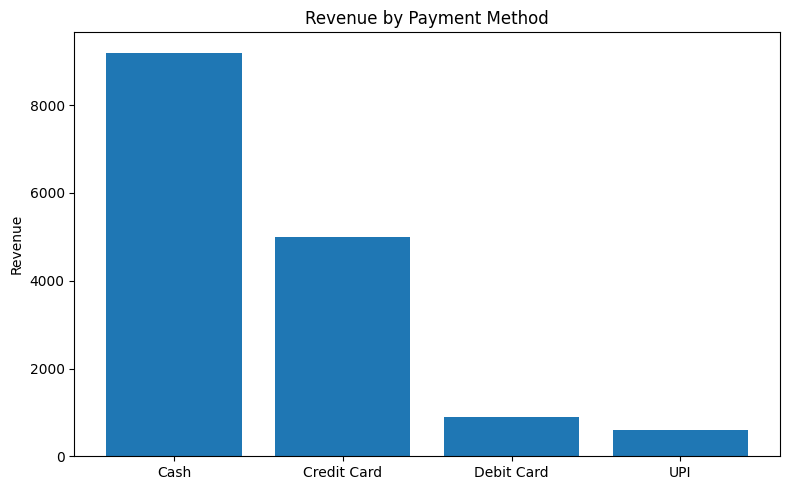

In [ ]:
# ==========================================================
# VISUALIZATION 1: REVENUE BY PAYMENT METHOD
# ----------------------------------------------------------
# Bar chart showing revenue distribution across payment methods
# Helps identify preferred payment channels and revenue streams
# ==========================================================

plt.figure(figsize=(8,5))
plt.bar(df_payment["PaymentMethod"], df_payment["Total_Revenue"])
plt.title("Revenue by Payment Method")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# ANALYTICAL QUERY: DIAGNOSIS FREQUENCY
# ----------------------------------------------------------
# Identify most common diagnoses
# Helps with resource planning and identifying prevalent conditions
# Limited to top 10 diagnoses
# Note: Variable name corrected from 'query' to 'query_diagnosis'
# ==========================================================

query_diagnosis = """
SELECT
    dx.DiagnosisName,
    COUNT(v.VisitID) AS Total_Cases
FROM All_Patient_Visits v
JOIN Dim_Diagnosis dx
    ON v.DiagnosisID = dx.DiagnosisID
GROUP BY dx.DiagnosisName
ORDER BY Total_Cases DESC
LIMIT 10;
"""

df = pd.read_sql_query(query, conn)
df.head()

,Month,Revenue
0,2024-01,1200
1,2024-02,900
2,2024-03,5000
3,2024-04,8000
4,2024-05,600


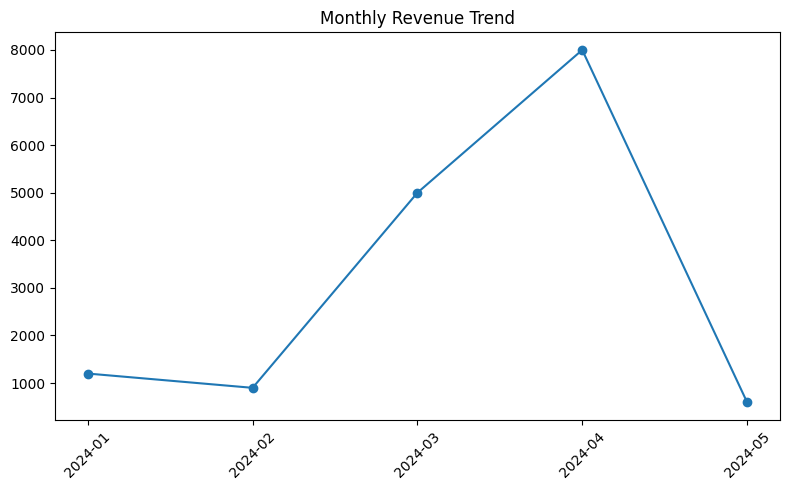

In [ ]:
# ==========================================================
# VISUALIZATION 2: MONTHLY REVENUE TREND
# ----------------------------------------------------------
# Line chart showing revenue trends over time
# Helps visualize seasonality and growth patterns
# ==========================================================

plt.figure(figsize=(8,5))
plt.plot(df["Month"], df["Revenue"], marker='o')
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# ANALYTICAL QUERY: DEPARTMENT WAIT TIMES
# ----------------------------------------------------------
# Extract wait time data by department for boxplot analysis
# Raw data for visualization
# ==========================================================

query = """
SELECT d.DepartmentName, v.WaitTimeMinutes
FROM All_Patient_Visits v
JOIN Dim_Department d ON v.DepartmentID = d.DepartmentID
"""

df = pd.read_sql_query(query, conn)
df.head()

,DepartmentName,WaitTimeMinutes
0,Dept- Cardiology,25
1,Dept- Neurology,15
2,Dept- Orthopedics,40
3,Dept- Oncology,35
4,Dept- Pediatrics,10


<Figure size 1000x600 with 0 Axes>

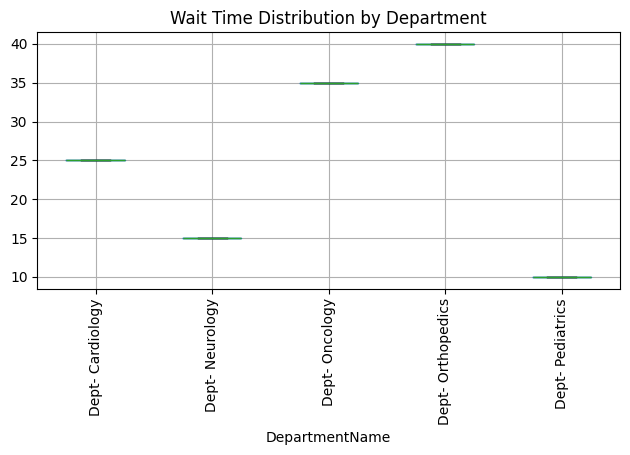

In [ ]:
# ==========================================================
# VISUALIZATION 3: WAIT TIME DISTRIBUTION BY DEPARTMENT
# ----------------------------------------------------------
# Box plot showing wait time distribution for each department
# Helps identify departments with long wait times
# Outliers and median wait times are clearly visible
# ==========================================================

plt.figure(figsize=(10,6))
df.boxplot(column="WaitTimeMinutes", by="DepartmentName", rot=90)
plt.title("Wait Time Distribution by Department")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# ANALYTICAL QUERY: PAYMENT METHOD DISTRIBUTION
# ----------------------------------------------------------
# Count transactions by payment method for pie chart
# ==========================================================

query = """
SELECT pm.PaymentMethod, COUNT(*) AS Transactions
FROM All_Patient_Visits v
JOIN Dim_PaymentMethod pm ON v.PaymentMethodID = pm.PaymentMethodID
GROUP BY pm.PaymentMethod
"""

df = pd.read_sql_query(query, conn)
df

,PaymentMethod,Transactions
0,Cash,2
1,Credit Card,1
2,Debit Card,1
3,UPI,1


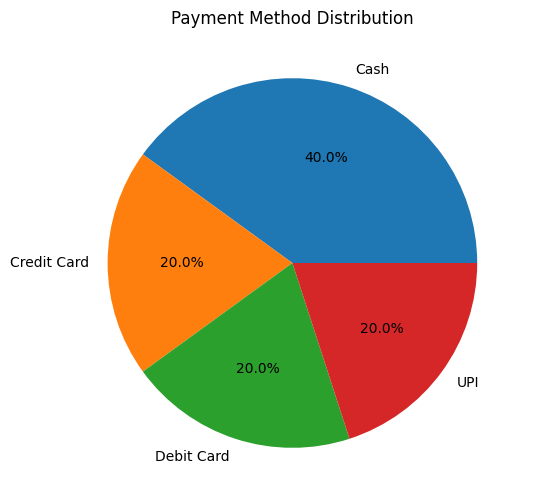

In [ ]:
# ==========================================================
# VISUALIZATION 4: PAYMENT METHOD DISTRIBUTION
# ----------------------------------------------------------
# Pie chart showing proportion of transactions by payment method
# Helps understand customer payment preferences
# ==========================================================

plt.figure(figsize=(6,6))
plt.pie(df["Transactions"], labels=df["PaymentMethod"], autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

In [ ]:
# ==========================================================
# ANALYTICAL QUERY: WAIT TIME VS SATISFACTION
# ----------------------------------------------------------
# Extract wait time and satisfaction score data for correlation analysis
# ==========================================================

query = """
SELECT WaitTimeMinutes, SatisfactionScore
FROM All_Patient_Visits
"""
df = pd.read_sql_query(query, conn)
df.tail()

,WaitTimeMinutes,SatisfactionScore
0,25,4
1,15,5
2,40,4
3,35,3
4,10,5


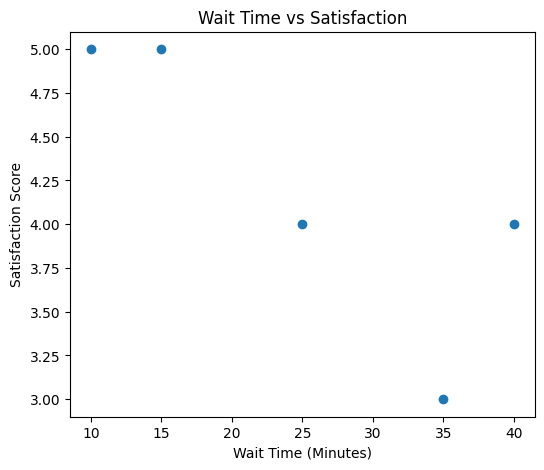

In [ ]:
# ==========================================================
# VISUALIZATION 5: WAIT TIME VS SATISFACTION SCATTER PLOT
# ----------------------------------------------------------
# Scatter plot showing relationship between wait time and satisfaction
# Helps identify optimal wait time targets
# Generally shows negative correlation (longer wait = lower satisfaction)
# ==========================================================

plt.figure(figsize=(6,5))
plt.scatter(df["WaitTimeMinutes"], df["SatisfactionScore"])
plt.title("Wait Time vs Satisfaction")
plt.xlabel("Wait Time (Minutes)")
plt.ylabel("Satisfaction Score")
plt.show()

In [ ]:
# ==========================================================
# ANALYTICAL QUERY: BILL AMOUNT DISTRIBUTION
# ----------------------------------------------------------
# Extract all bill amounts for histogram analysis
# ==========================================================

query = "SELECT BillAmount FROM All_Patient_Visits"
df = pd.read_sql_query(query, conn)
df

,BillAmount
0,1200
1,900
2,5000
3,8000
4,600


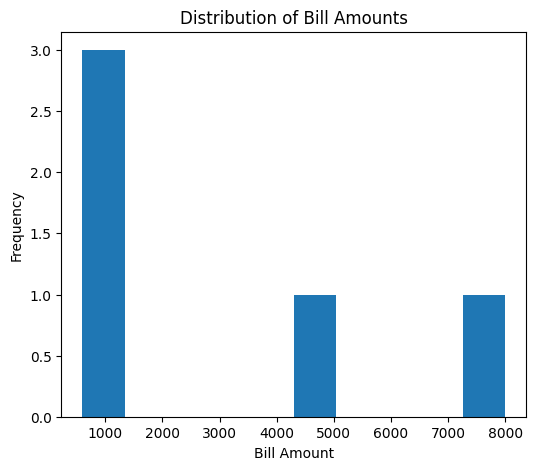

In [ ]:
# ==========================================================
# VISUALIZATION 6: BILL AMOUNT HISTOGRAM
# ----------------------------------------------------------
# Histogram showing distribution of bill amounts
# Helps understand revenue concentration
# Identifies typical visit costs and outliers
# ==========================================================

plt.figure(figsize=(6,5))
plt.hist(df["BillAmount"], bins=10)
plt.title("Distribution of Bill Amounts")
plt.xlabel("Bill Amount")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# ==========================================================
# ANALYTICAL QUERY: DEPARTMENT WAIT TIME DATA EXTRACTION
# ----------------------------------------------------------
# Retrieve wait time data for each department to analyze
# operational efficiency and patient experience metrics.
# This query joins fact table with department dimension
# to enable department-level analysis of wait times.
# ==========================================================

query = """
SELECT d.DepartmentName, v.WaitTimeMinutes
FROM All_Patient_Visits v
JOIN Dim_Department d ON v.DepartmentID = d.DepartmentID
"""
df = pd.read_sql_query(query, conn)
df

,DepartmentName,WaitTimeMinutes
0,Dept- Cardiology,25
1,Dept- Neurology,15
2,Dept- Orthopedics,40
3,Dept- Oncology,35
4,Dept- Pediatrics,10


<Figure size 1000x600 with 0 Axes>

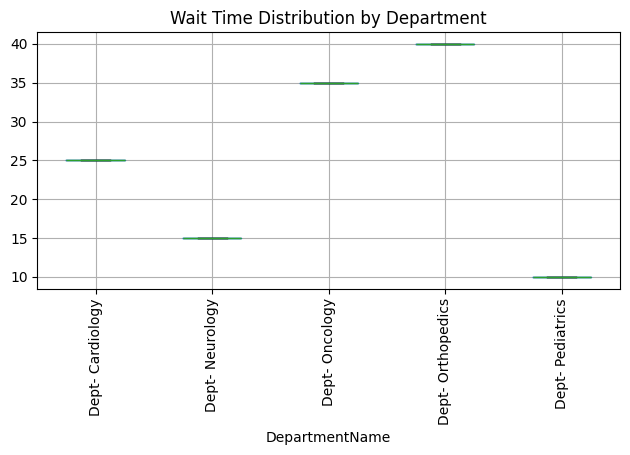

In [ ]:
# ==========================================================
# VISUALIZATION: WAIT TIME DISTRIBUTION BY DEPARTMENT
# ----------------------------------------------------------
# Box plot analysis to compare wait time patterns across departments.
# Key insights from this visualization:
# - Identifies departments with consistently long wait times
# - Shows variability (spread) of wait times within each department
# - Highlights outliers (unusually long/short wait times)
# - Median line shows typical wait time for each department
# ==========================================================

plt.figure(figsize=(10,6))
df.boxplot(column="WaitTimeMinutes", by="DepartmentName", rot=90)
plt.title("Wait Time Distribution by Department")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
# PROJECT SUMMARY
# ----------------------------------------------------------
# ✔ Designed Star Schema data warehouse
# ✔ Created dimension and fact tables
# ✔ Built unified analytical SQL view
# ✔ Performed business intelligence queries
# ✔ Created multiple data visualizations
#
# This project demonstrates SQL, data modeling,
# analytics, and visualization skills.
# ==========================================================